In [1]:
!kaggle datasets download mikhailpoplevin/isic2019and2020resized

Dataset URL: https://www.kaggle.com/datasets/mikhailpoplevin/isic2019and2020resized
License(s): CC0-1.0
100% 1.07G/1.07G [00:53<00:00, 21.3MB/s]



In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_curve, f1_score, precision_score, recall_score, fbeta_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay, PrecisionRecallDisplay, roc_curve
import tqdm

import torch.utils.data as data
import torchvision.transforms.v2 as v2
import torch
import torch.nn as nn
from torchinfo import summary
from PIL import Image

sns.set_theme(context="notebook", palette="muted")

In [11]:
labels = pd.read_parquet('meta_and_target.parquet')
labels['stratify_col'] = labels['source'].astype(str) + '_' + labels['target'].astype(str)

In [12]:
sex_map = {
    'male' : torch.tensor([1, 0], dtype=torch.float32),
    'female' : torch.tensor([0, 1], dtype=torch.float32),
    None : torch.zeros(2, dtype=torch.float32)
}
anatom_site_map = {'head/neck': torch.tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float32),
                    'upper extremity': torch.tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float32),
                    'lower extremity': torch.tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.], dtype=torch.float32),
                    'torso': torch.tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], dtype=torch.float32),
                    None: torch.tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.], dtype=torch.float32),
                    'palms/soles': torch.tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], dtype=torch.float32),
                    'oral/genital': torch.tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], dtype=torch.float32),
                    'anterior torso': torch.tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.], dtype=torch.float32),
                    'posterior torso': torch.tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], dtype=torch.float32),
                    'lateral torso': torch.tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=torch.float32)}

source_map = {'2020' : torch.tensor([1], dtype=torch.float32), '2019' : torch.tensor([0], dtype=torch.float32)}

class ISICDataset(data.Dataset):
    def __init__(self, root, labels, transforms, anatom_site_map, gender_map, source_map):
        super().__init__()
        self.root = root
        self.labels = labels
        self.transforms = transforms
        self.anatom_site_map = anatom_site_map
        self.gender_map = gender_map
        self.source_map = source_map
        self.files = [self.root + f'/{image_id}.jpg' for image_id in self.labels['image'].astype(str).tolist()]
        self.targets = self.labels['target'].astype(float).tolist()
        self.anatom_site = self.labels['anatom_site_general'].tolist()
        self.gender = self.labels['sex'].tolist()
        self.age = self.labels['age_approx'].tolist()
        self.source = self.labels['source'].astype(str).tolist()

    def __len__(self):
        return len(self.files)

    def _get_age_meta(self, age):
        if pd.isna(age):
            return torch.tensor([0.0], dtype=torch.float32)
        return torch.tensor([float(age) / 100.0], dtype=torch.float32)

    def _get_anatom_site_meta(self, site):
        if pd.isna(site):
            site = None
        return self.anatom_site_map.get(site, self.anatom_site_map[None])

    def _get_sex_meta(self, sex):
        if pd.isna(sex):
            sex = None
        return self.gender_map.get(sex, self.gender_map[None])

    def _get_source_meta(self, source):
        return self.source_map[source]

    def __getitem__(self, index):
        image_path = self.files[index]

        with Image.open(image_path) as im:
            im = im.convert('RGB')

        if self.transforms is not None:
            im = self.transforms(im)

        age_meta = self._get_age_meta(self.age[index])
        anatom_site_meta = self._get_anatom_site_meta(self.anatom_site[index])
        sex_meta = self._get_sex_meta(self.gender[index])
        source_meta = self._get_source_meta(self.source[index])
        meta = torch.cat([age_meta, anatom_site_meta, sex_meta, source_meta], dim=0)
        target = torch.tensor(self.targets[index], dtype=torch.float32)

        return im, meta, target

In [16]:
from torchvision.models import resnet152, ResNet152_Weights

class Multimodal(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.conv = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)
        for p in self.conv.parameters():
            p.requires_grad = False
        
        self.conv.fc = nn.Sequential(nn.Linear(2048, 512), nn.ReLU())
        for p in self.conv.fc.parameters():
            p.requires_grad = True

        self.metaclf = nn.Sequential(
            nn.Linear(14, 64),
            nn.GELU(),
            nn.Linear(64, 64, bias=False),
            nn.BatchNorm1d(64),
            nn.GELU()
        )

        self.clf = nn.Sequential(
            nn.Linear(512 + 64, 64, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, X, meta):
        with torch.no_grad():
            X = self.conv(X)
        meta = self.metaclf(meta)
        return self.clf(torch.cat([X, meta], dim=1))

In [82]:
train_labels, test_labels = train_test_split(labels, test_size=0.3, random_state=34, stratify=labels['stratify_col'])
test_labels, val_labels = train_test_split(test_labels, test_size=0.35, random_state=34, stratify=test_labels['stratify_col'])

test_transforms = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, True), v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

test_dataset = ISICDataset('data/images', test_labels, transforms=test_transforms, anatom_site_map=anatom_site_map, gender_map=sex_map, source_map=source_map)
test_loader = data.DataLoader(test_dataset, batch_size=128)

device = torch.device('cuda')

model = Multimodal()
model.load_state_dict(torch.load('drive/MyDrive/gp5/multimodal/resnet152multimodal/checkpoints/best.pt', weights_only=False)['model_state'])
model.to(device);
probs = []
targets = []
for im, meta, y in tqdm.tqdm(test_loader):
    im = im.to(device)
    meta = meta.to(device)
    y = y.to(device)

    with torch.no_grad():
        logits = model(im, meta)

    targets.extend(y.cpu().detach().numpy().flatten().tolist())
    probs.extend(logits.float().sigmoid().cpu().detach().numpy().flatten().tolist())

100%|██████████| 102/102 [01:04<00:00,  1.57it/s]


In [71]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay, auc, average_precision_score, accuracy_score, precision_score, recall_score, fbeta_score


def get_predictions(probs, threshold=0.5):
    return (np.asarray(probs) >= threshold).astype(int)


def calculate_metrics(targets, probs=None, preds=None, threshold=0.5, beta=1.0):
    metrics = {
        "accuracy": accuracy_score(targets, preds),
        "precision": precision_score(targets, preds, zero_division=0),
        "recall": recall_score(targets, preds, zero_division=0),
        "fscore": fbeta_score(targets, preds, beta=beta, zero_division=0),
    }

    return metrics


def print_metrics(targets, probs=None, preds=None, threshold=0.5, beta=1.0):
    metrics = calculate_metrics(
        targets=targets,
        probs=probs,
        preds=preds,
        threshold=threshold,
        beta=beta)

    print(f"Threshold : {threshold:.3f}")
    print(f"Accuracy  : {metrics['accuracy']:.4f}")
    print(f"Precision : {metrics['precision']:.4f}")
    print(f"Recall    : {metrics['recall']:.4f}")
    print(f"F{beta:g}-score  : {metrics['fscore']:.4f}")

    return metrics


def plot_confusion_matrix(targets, probs=None, preds=None, threshold=0.5, labels=("Negative", "Positive"), normalize=None, title="Confusion Matrix"):
    if preds is None:
        if probs is None:
            raise ValueError("Передай либо probs, либо preds.")
        preds = get_predictions(probs, threshold)

    cm = confusion_matrix(targets, preds, normalize=normalize)

    fig, ax = plt.subplots(figsize=(6, 5), dpi=130)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    display.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f" if normalize else "d")

    ax.set_title(title, fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    for text in ax.texts:
        text.set_fontsize(13)
        text.set_fontweight("bold")

    plt.tight_layout()
    plt.show()

    return fig, ax

def plot_roc_curve(targets, probs, title="ROC Curve", estimator_name="Model", show_best_threshold=True,):

    fpr, tpr, thresholds = roc_curve(targets, probs)
    roc_auc = auc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(7, 6), dpi=130)
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=estimator_name)
    display.plot(ax=ax, color="#2563eb", linewidth=2.8, name=f"ROC curve  |  AUC = {roc_auc:.3f}")

    ax.fill_between(fpr, tpr, alpha=0.10, color="#2563eb")
    ax.plot([0, 1], [0, 1], linestyle="--", color="#9ca3af", linewidth=1.5, label="Random classifier")

    if show_best_threshold:
        best_idx = np.argmax(tpr - fpr)
        best_threshold = thresholds[best_idx]

        ax.scatter(fpr[best_idx], tpr[best_idx], s=90, color="#dc2626", edgecolor="white", linewidth=1.5, zorder=5, label=f"Best threshold = {best_threshold:.3f}")

        ax.annotate(
            f"threshold = {best_threshold:.3f}",
            xy=(fpr[best_idx], tpr[best_idx]),
            xytext=(18, -18),
            textcoords="offset points",
            fontsize=10,
            color="#374151",
            arrowprops=dict(arrowstyle="->", color="#6b7280", lw=1)
        )

    ax.set_title(title, fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)

    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax.legend(loc="lower right", frameon=True, fontsize=10)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

    return fig, ax


def plot_pr_curve(targets, probs, title="Precision-Recall Curve", estimator_name="Model", show_best_threshold=True):
    precision, recall, thresholds = precision_recall_curve(targets, probs)
    avg_precision = average_precision_score(targets, probs)
    fig, ax = plt.subplots(figsize=(7, 6), dpi=130)
    display = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=avg_precision, estimator_name=estimator_name)

    display.plot(ax=ax, color="#16a34a", linewidth=2.8, name=f"PR curve  |  AP = {avg_precision:.3f}")
    ax.fill_between(recall, precision, alpha=0.10, color="#16a34a")
    baseline = np.mean(targets)
    ax.axhline(baseline, linestyle="--", color="#9ca3af", linewidth=1.5, label=f"Baseline = {baseline:.3f}")

    if show_best_threshold:
        precision_t = precision[:-1]
        recall_t = recall[:-1]
        f1_scores = 2 * precision_t * recall_t / (precision_t + recall_t + 1e-12)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        ax.scatter(recall_t[best_idx], precision_t[best_idx], s=90, color="#dc2626", edgecolor="white", linewidth=1.5, zorder=5, label=f"Best threshold = {best_threshold:.3f}")
        ax.annotate(f"threshold = {best_threshold:.3f}", xy=(recall_t[best_idx], precision_t[best_idx]), xytext=(-95, -18), textcoords="offset points", fontsize=10, color="#374151", arrowprops=dict(arrowstyle="->", color="#6b7280", lw=1))

    ax.set_title(title, fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)

    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax.legend(loc="lower left", frameon=True, fontsize=10)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

    return fig, ax


def evaluate_binary_classifier(targets, probs, threshold=0.5, beta=1.0, labels=("Negative", "Positive")):
    preds = get_predictions(probs, threshold)
    metrics = print_metrics(targets=targets, preds=preds, threshold=threshold, beta=beta)
    plot_confusion_matrix(targets=targets, preds=preds, threshold=threshold, labels=labels)
    plot_roc_curve(targets=targets, probs=probs)
    plot_pr_curve(targets=targets, probs=probs)
    return metrics

Threshold : 0.386
Accuracy  : 0.7674
Precision : 0.2666
Recall    : 0.8056
F1-score  : 0.4006


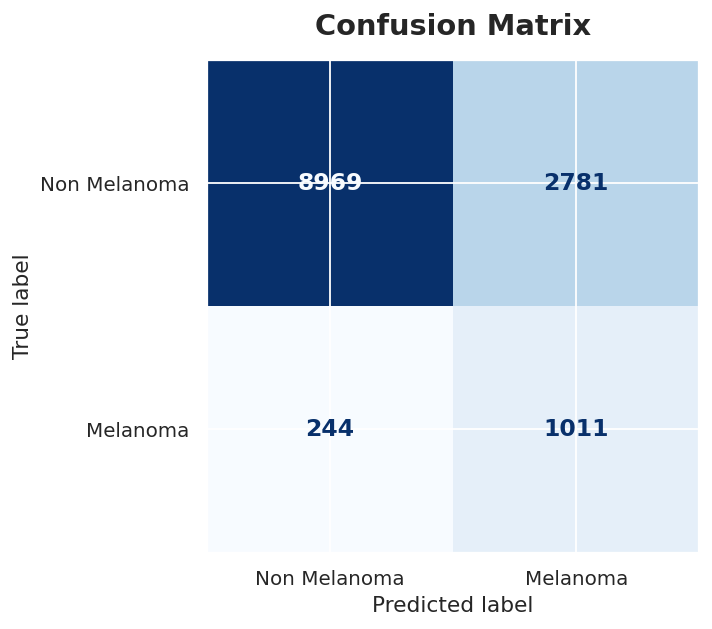

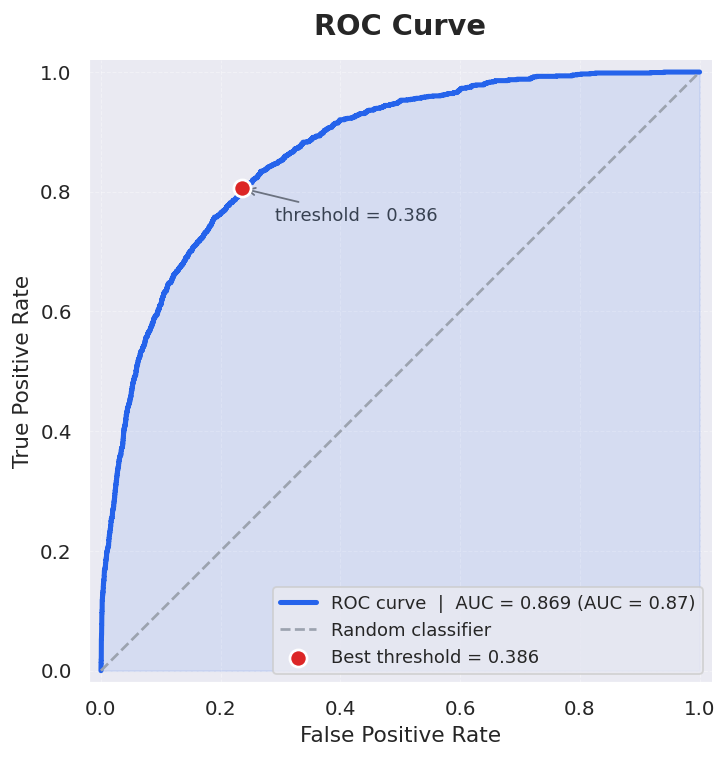

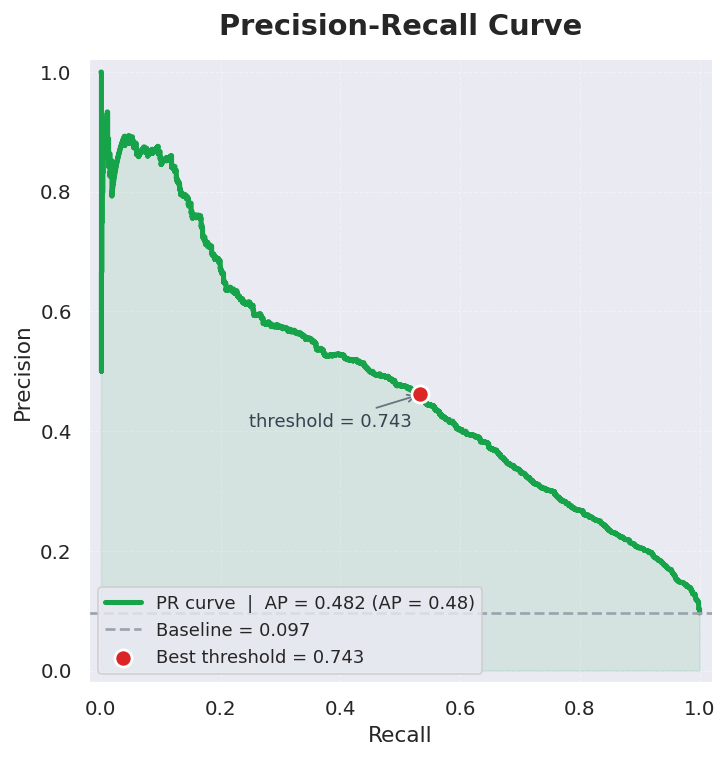

In [83]:
metrics = evaluate_binary_classifier(targets=targets, probs=probs, threshold=0.386, labels=("Non Melanoma", "Melanoma"))

In [84]:
train_labels, test_labels = train_test_split(labels, test_size=0.3, random_state=34, stratify=labels['stratify_col'])
test_labels, val_labels = train_test_split(test_labels, test_size=0.35, random_state=34, stratify=test_labels['stratify_col'])

test_transforms = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, True), v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

test_dataset = ISICDataset('data/images', test_labels, transforms=test_transforms, anatom_site_map=anatom_site_map, gender_map=sex_map, source_map=source_map)
test_loader = data.DataLoader(test_dataset, batch_size=128)

device = torch.device('cuda')

model = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)

for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Linear(512, 1)
)

model.load_state_dict(torch.load('drive/MyDrive/gp5/resnet152/checkpoints/best.pt', weights_only=False)['model_state'])
model.to(device);
probs = []
targets = []

In [85]:
for im, _, y in tqdm.tqdm(test_loader):
    im = im.to(device)
    y = y.to(device)

    with torch.no_grad():
        logits = model(im)

    targets.extend(y.cpu().detach().numpy().flatten().tolist())
    probs.extend(logits.float().sigmoid().cpu().detach().numpy().flatten().tolist())

100%|██████████| 102/102 [01:04<00:00,  1.58it/s]


Threshold : 0.287
Accuracy  : 0.7769
Precision : 0.2699
Recall    : 0.7697
F1-score  : 0.3997


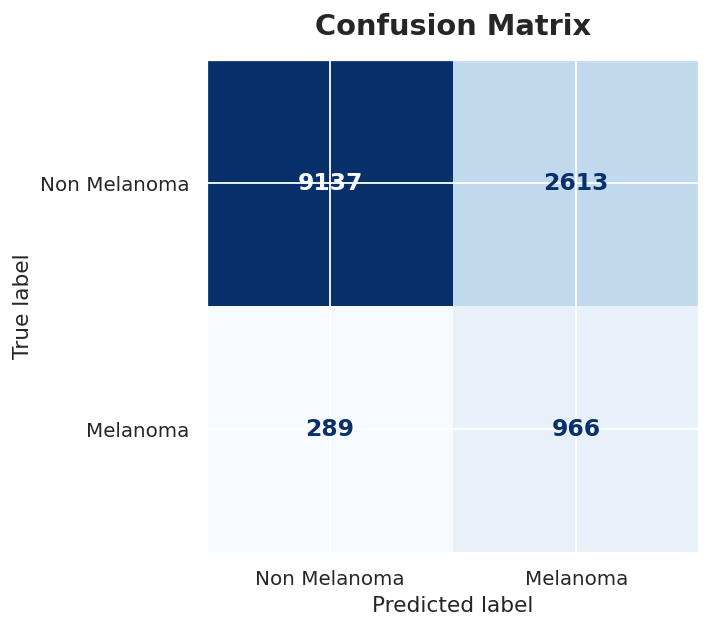

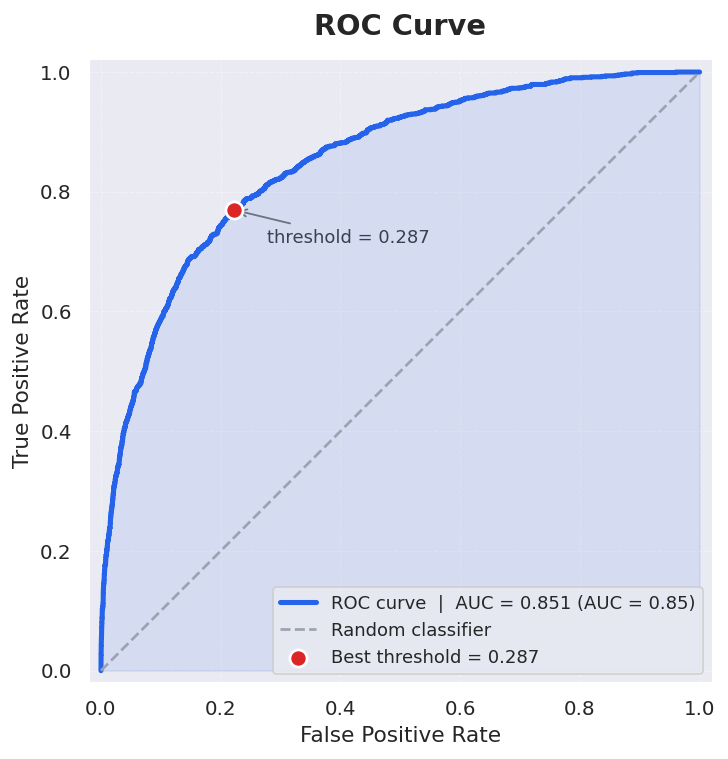

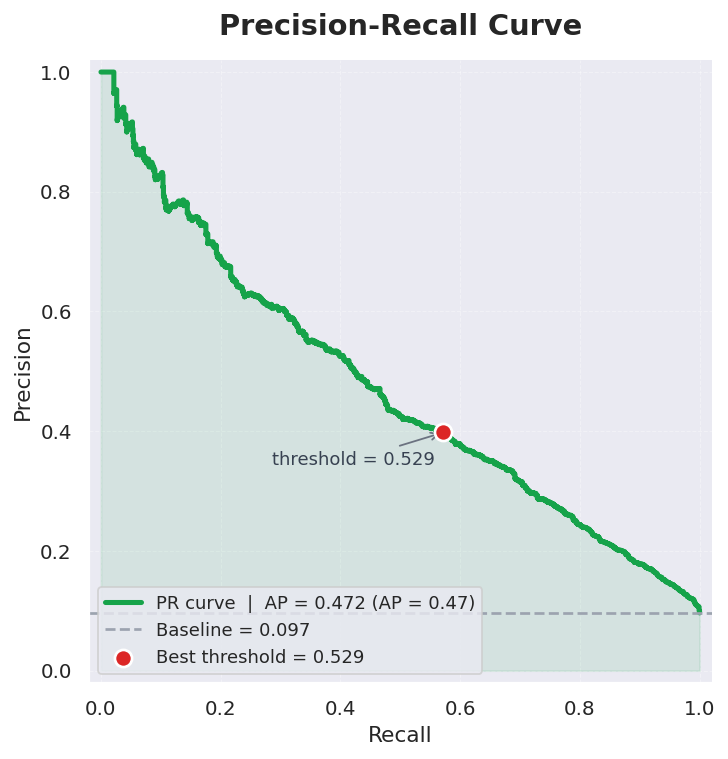

In [88]:
metrics = evaluate_binary_classifier(targets=targets, probs=probs, threshold=0.287, labels=("Non Melanoma", "Melanoma"))

In [91]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )

        if in_ch != out_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.skip = nn.Identity()

        self.act = nn.PReLU(num_parameters=out_ch)

    def forward(self, x):
        return self.act(self.block(x) + self.skip(x))


class CustomModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.stage1 = self._make_stage(3, 64, num_blocks=2, stride=1)
        self.stage2 = self._make_stage(64, 128, num_blocks=2, stride=2)
        self.stage3 = self._make_stage(128, 256, num_blocks=7, stride=2)
        self.stage4 = self._make_stage(256, 512, num_blocks=9, stride=2)

        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(4 * 4 * 512, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1)
        )

        self._init_weights()

    def _make_stage(self, in_ch, out_ch, num_blocks, stride):
        blocks = [ResBlock(in_ch, out_ch, stride=stride)]
        for _ in range(num_blocks - 1):
            blocks.append(ResBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*blocks)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.fc(x)
        return x

train_labels, test_labels = train_test_split(labels, test_size=0.3, random_state=34, stratify=labels['stratify_col'])
test_labels, val_labels = train_test_split(test_labels, test_size=0.35, random_state=34, stratify=test_labels['stratify_col'])

test_transforms = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, True), v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

test_dataset = ISICDataset('data/images', test_labels, transforms=test_transforms, anatom_site_map=anatom_site_map, gender_map=sex_map, source_map=source_map)
test_loader = data.DataLoader(test_dataset, batch_size=128)

device = torch.device('cuda')

model = CustomModel()

model.load_state_dict(torch.load('drive/MyDrive/gp5/best.pt', weights_only=False)['model_state'])
model.to(device);
probs = []
targets = []

In [92]:
for im, _, y in tqdm.tqdm(test_loader):
    im = im.to(device)
    y = y.to(device)

    with torch.no_grad():
        logits = model(im)

    targets.extend(y.cpu().detach().numpy().flatten().tolist())
    probs.extend(logits.float().sigmoid().cpu().detach().numpy().flatten().tolist())

100%|██████████| 102/102 [02:35<00:00,  1.53s/it]


Threshold : 0.535
Accuracy  : 0.7810
Precision : 0.2782
Recall    : 0.7960
F1-score  : 0.4123


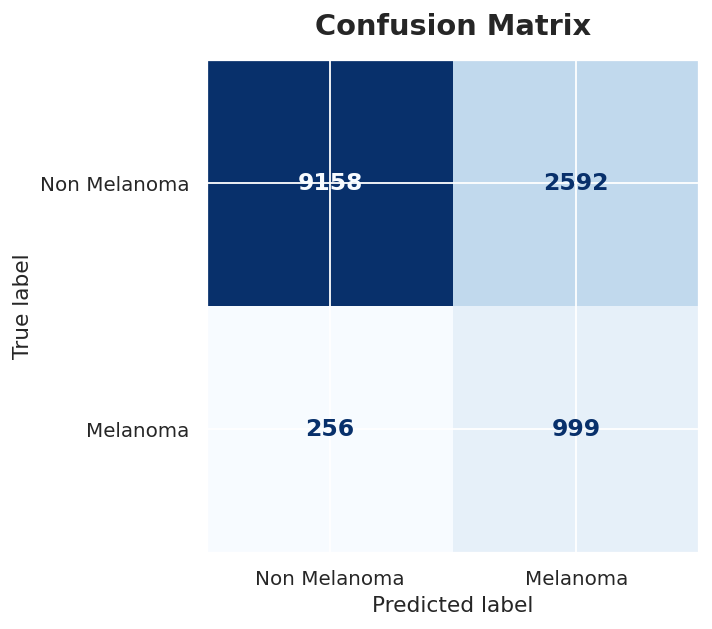

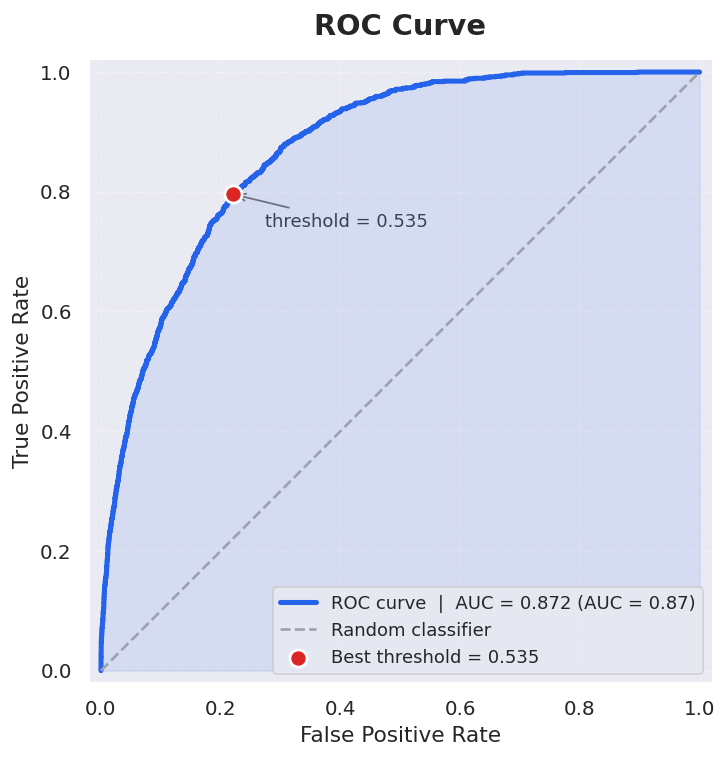

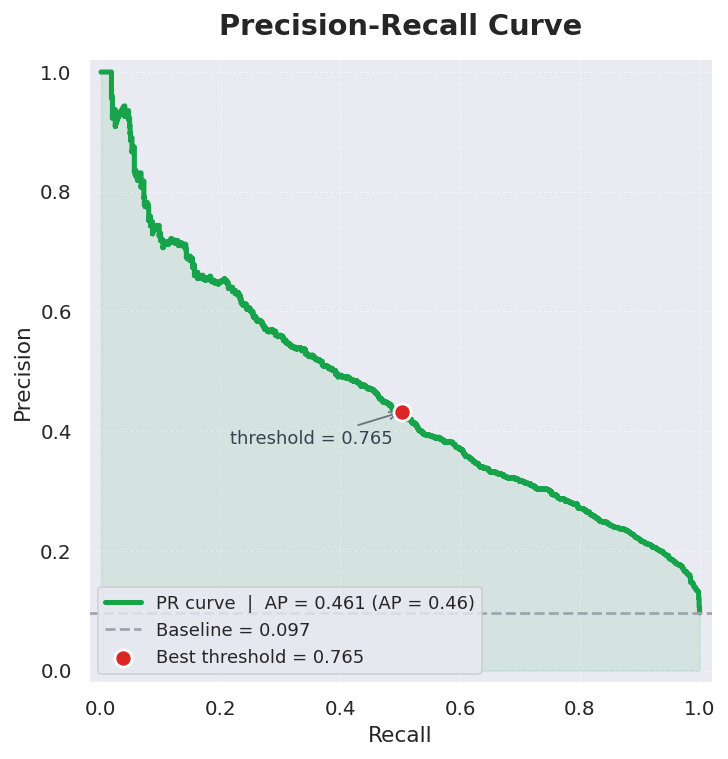

In [95]:
metrics = evaluate_binary_classifier(targets=targets, probs=probs, threshold=0.535, labels=("Non Melanoma", "Melanoma"))

In [97]:
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.GELU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.GELU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.GELU(),
    nn.MaxPool2d(2),

    nn.Conv2d(128, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.GELU(),
    nn.MaxPool2d(2),

    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.GELU(),

    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),

    nn.Linear(256, 64),
    nn.GELU(),
    nn.Dropout(0.3),

    nn.Linear(64, 1)
)

train_labels, test_labels = train_test_split(labels, test_size=0.3, random_state=34, stratify=labels['stratify_col'])
test_labels, val_labels = train_test_split(test_labels, test_size=0.35, random_state=34, stratify=test_labels['stratify_col'])

test_transforms = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, True), v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

test_dataset = ISICDataset('data/images', test_labels, transforms=test_transforms, anatom_site_map=anatom_site_map, gender_map=sex_map, source_map=source_map)
test_loader = data.DataLoader(test_dataset, batch_size=128)

device = torch.device('cuda')

model.load_state_dict(torch.load('drive/MyDrive/gp5/best.pt', weights_only=False)['model_state'])
model.to(device);
probs = []
targets = []

In [98]:
for im, _, y in tqdm.tqdm(test_loader):
    im = im.to(device)
    y = y.to(device)

    with torch.no_grad():
        logits = model(im)

    targets.extend(y.cpu().detach().numpy().flatten().tolist())
    probs.extend(logits.float().sigmoid().cpu().detach().numpy().flatten().tolist())

100%|██████████| 102/102 [00:27<00:00,  3.73it/s]


Threshold : 0.517
Accuracy  : 0.7446
Precision : 0.2497
Recall    : 0.8215
F1-score  : 0.3830


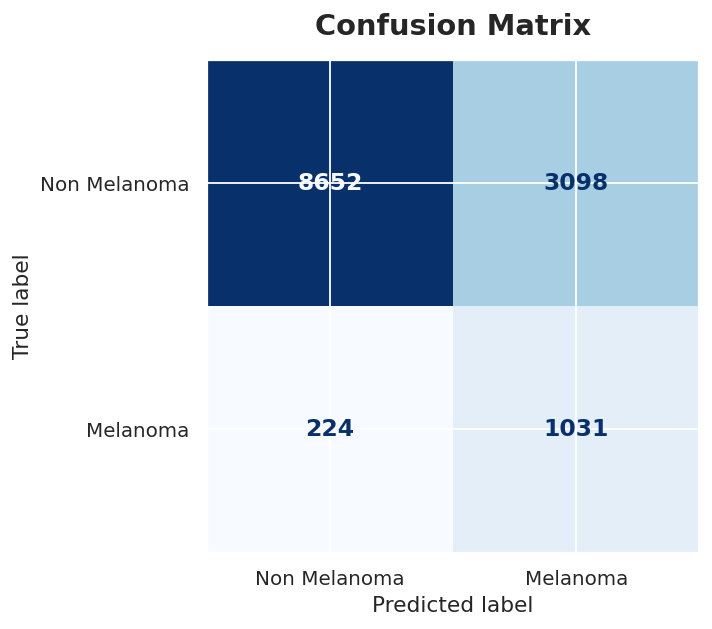

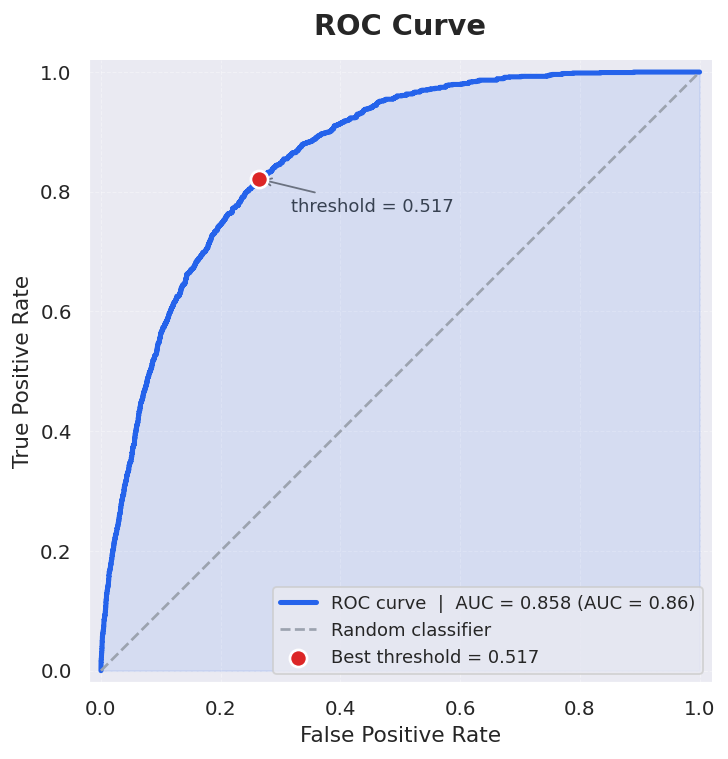

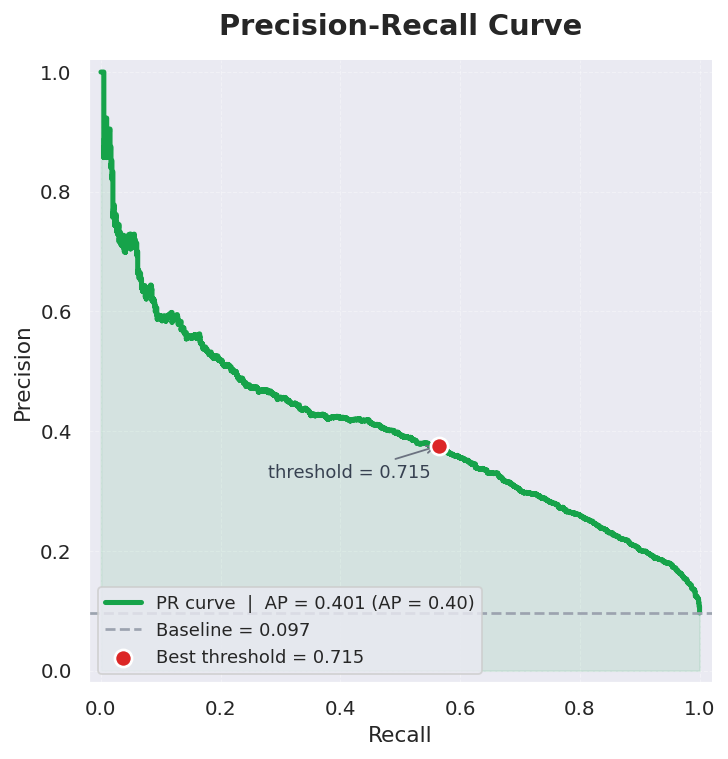

In [100]:
metrics = evaluate_binary_classifier(targets=targets, probs=probs, threshold=0.517, labels=("Non Melanoma", "Melanoma"))